In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as w
import time

Function to generate the values for a sine wave given the amplitude, frequency, phase, and time array

In [2]:
def sine(t, amp, freq, phase):
    y = np.zeros(len(t))
    y += amp * np.sin(2*np.pi*freq*t+phase)
    return y

Naive implementation of a discrete fourier transform (DFT) in Python. This implementation has a time complexity of O(N^2) and is therefore basically never used for calculations in practice. In real-time applications, the Fast Fourier Transform (FFT) algorithm is preferred due to its significantly lower time complexity of O(N log N).

In [3]:
def dft(x):
    N = len(x)
    res = np.arange(N)
    k = res.reshape(-1, 1)
    return np.dot(np.exp(-1j*(2*np.pi*k*res/N)), x)

Basic implementation of the Cooley-Tukey Fast Fourier Transform (FFT) algorithm in Python. This implementation recursively divides the DFT into smaller DFTs, significantly reducing the time complexity, but due to the recursion overhead the speedup compared to the naive DFT implementation may not be substantial for small input sizes.

In [4]:
# Cooley-Tukey FFT
def ditfft2(x):
    N = len(x)
    if N == 1:
        return np.array(x, dtype=complex)
    even = ditfft2(x[::2])
    odd = ditfft2(x[1::2])
    factor = np.exp(-2j * np.pi * np.arange(N // 2) / N)
    return np.concatenate([even + factor * odd, even - factor * odd])
      

Iterative solution of the FFT algorithm that basically builds up the FFT result in a bottom-up manner using bit-reversal permutation and iterative computation of smaller DFTs. 
It also precomputes the twiddle factors (complex roots of unity) to avoid redundant calculations, further improving the efficiency compared to the naive DFT implementation.

In [5]:
def fft_iter(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    bits = N.bit_length() - 1

    # bit-reversal
    indices = np.arange(N)
    reversed_indices = np.zeros(N, dtype=np.int64)
    for b in range(bits):
        bit = (indices >> b) & 1
        reversed_indices |= bit << (bits - 1 - b)
    x = x[reversed_indices]

    # precompute twiddle table
    twiddle_table = np.exp(-2j * np.pi * np.arange(N // 2) / N)

    size = 2
    while size <= N:
        half = size // 2
        x = x.reshape(-1, size)     
        w = twiddle_table[:: N // size]
        even = x[:, :half]
        odd = x[:, half:] * w
        out = np.empty_like(x)
        out[:, :half] = even + odd
        out[:, half:] = even - odd
        x = out
        size *= 2
    return x.reshape(-1)

Visualization of the FFT results, letting you create your own signals with different parameters and then display the combined signal alongside its frequency spectrum.
In the last plot it also shows a comparison of the execution times of the naive DFT and the FFT implementations.

Compare DFT and FFT results:  False


Button(description='Randomize sliders', style=ButtonStyle())

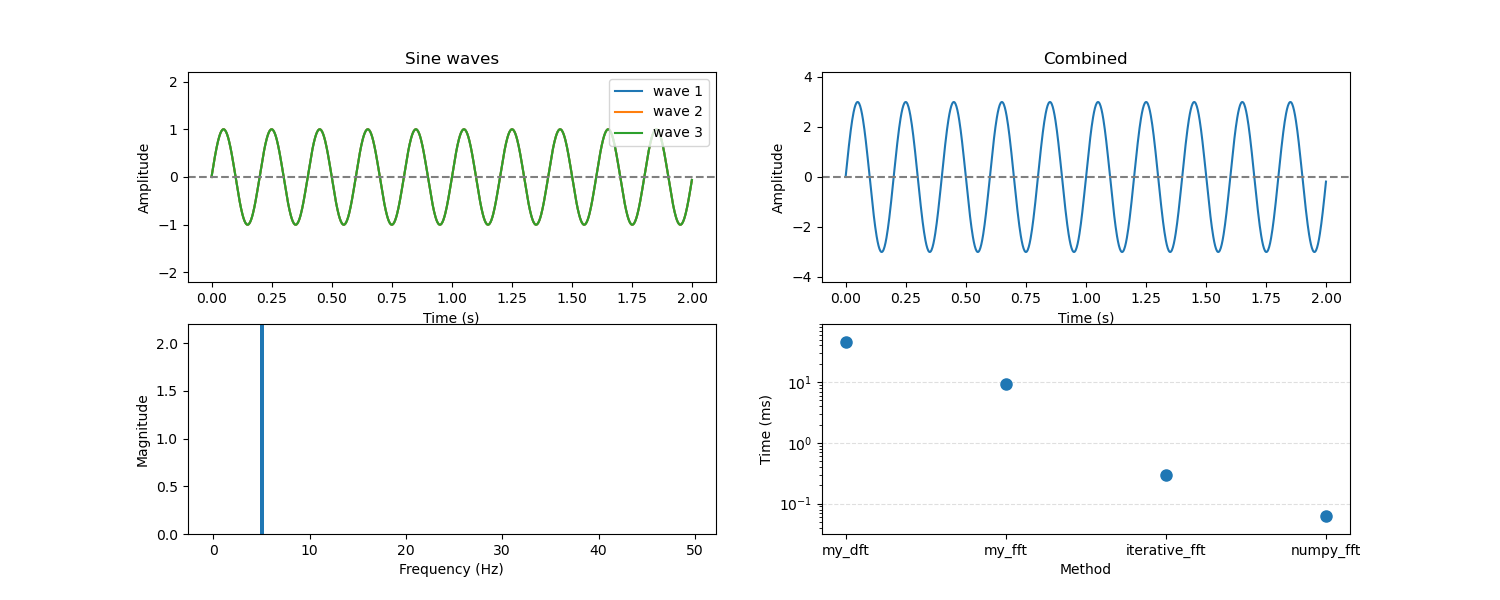

In [7]:
N = 1024
sample_rate = 512
t = np.arange(N) / sample_rate
freqs = np.arange(N) * sample_rate / N
dft_res = np.zeros(N, dtype=complex)
magnitudes = np.abs(dft_res) / (N/2)
types = ['my_dft', 'my_fft', 'iterative_fft', 'numpy_fft']

def make_sliders(freq=5.0, amp=1.0, phase=0.0):
    return {
        "freq":  w.FloatSlider(min=1,   max=50,     step=0.5, value=freq,  description="Freq (Hz)"),
        "amp":   w.FloatSlider(min=0.1, max=2.0,    step=0.1, value=amp,   description="Amp"),
        "phase": w.FloatSlider(min=0,   max=2*np.pi, step=0.1, value=phase, description="Phase"),
    }

n_waves = 3
sliders = [make_sliders() for _ in range(n_waves)]

fig, ax = plt.subplots(2, 2, figsize=(15, 6))
fig.canvas.header_visible = False

lines = [ax[0, 0].plot(t, np.zeros(N), label=f"wave {i+1}")[0] for i in range(n_waves)]
combined_line, = ax[0, 1].plot(t, np.zeros(N))

ax[0, 0].set_ylim(-2.2, 2.2)
ax[0, 0].set_title("Sine waves")
ax[0, 0].legend(loc="upper right")
ax[0, 1].set_ylim(-4.2, 4.2)
ax[0, 1].set_title("Combined")

for j in range(2):
    ax[0, j].set_xlabel("Time (s)")
    ax[0, j].set_ylabel("Amplitude")
    ax[0, j].axhline(0, color="gray", linestyle="--")

dft_bins = 100
dft_bars = ax[1, 0].bar(freqs[:dft_bins], magnitudes[:dft_bins], width=0.4)
ax[1, 0].set_xlabel("Frequency (Hz)")
ax[1, 0].set_ylabel("Magnitude")
ax[1, 0].set_ylim(0, 2.2)
time_points, = ax[1, 1].plot(types, np.ones(len(types)), "o", markersize=8)
ax[1, 1].set_xlabel("Method")
ax[1, 1].set_ylabel("Time (ms)")
ax[1, 1].set_yscale("log")
ax[1, 1].grid(axis="y", which="major", linestyle="--", alpha=0.4)

def time_method(method, data):
    start_timer = time.perf_counter()
    method(data)
    return time.perf_counter() - start_timer

def update(change=None):
    ys = [sine(t, s["amp"].value, s["freq"].value, s["phase"].value) for s in sliders]
    for line, y in zip(lines, ys):
        line.set_ydata(y)
    combined_data = np.sum(ys, axis=0)
    
    my_dft_time = time_method(dft, combined_data)
    my_fft_time = time_method(ditfft2, combined_data)
    my_iter_fft_time = time_method(fft_iter, combined_data)
    np_fft_time = time_method(np.fft.fft, combined_data)

    timing_values = np.array([my_dft_time, my_fft_time, my_iter_fft_time, np_fft_time]) * 1000
    time_points.set_ydata(timing_values)
    ax[1, 1].set_ylim(timing_values.min() * 0.5, timing_values.max() * 2)
    combined_line.set_ydata(combined_data)
    fft_res = fft_iter(combined_data)
    magnitudes = np.abs(fft_res) / (N/2)
    print("Compare DFT and FFT results: ", np.allclose(dft_res, fft_res))
    for bar, magnitude in zip(dft_bars, magnitudes[:dft_bins]):
        bar.set_height(magnitude)
    fig.canvas.draw_idle()

def randomize_sliders(change=None):
    for s in sliders:
        s["freq"].value = np.random.uniform(1, 50)
        s["amp"].value = np.random.uniform(0.1, 2.0)
        s["phase"].value = np.random.uniform(0, 2*np.pi)

for s in sliders:
    for slider in s.values():
        slider.observe(update, names="value")
update()

slider_groups = [
    w.VBox([
        w.HTML(
            value=f"<div style='text-align: center;'><b>Wave {i + 1}</b></div>",
            layout=w.Layout(width="100%"),
        ),
        *s.values(),
    ])
    for i, s in enumerate(sliders)
 ]
display(w.HBox(slider_groups))

randomize_button = w.Button(description="Randomize sliders")
randomize_button.on_click(randomize_sliders)
display(randomize_button)

The results show that the FFT correctly isolates the individual frequency components of the signal. The execution time comparison also demonstrates the time decreases of the different FFT implementations compared to the naive DFT.